File CSV yang ada di folder ini: ['Market_Basket_Optimisation.csv']
Bentuk data mentah (baris x kolom maks): (7501, 20)
Jumlah transaksi: 7501

Jumlah transaksi      : 7501
Jumlah produk unik    : 119
Total item terjual    : 29363
Rata-rata item/keranjang: 3.91 (median 3, maks 20, min 1)

10 produk terlaris:
  mineral water              1788  (23.84% transaksi)
  eggs                       1348  (17.97% transaksi)
  spaghetti                  1306  (17.41% transaksi)
  french fries               1282  (17.09% transaksi)
  chocolate                  1230  (16.40% transaksi)
  green tea                   991  (13.21% transaksi)
  milk                        972  (12.96% transaksi)
  ground beef                 737  (9.83% transaksi)
  frozen vegetables           715  (9.53% transaksi)
  pancakes                    713  (9.51% transaksi)


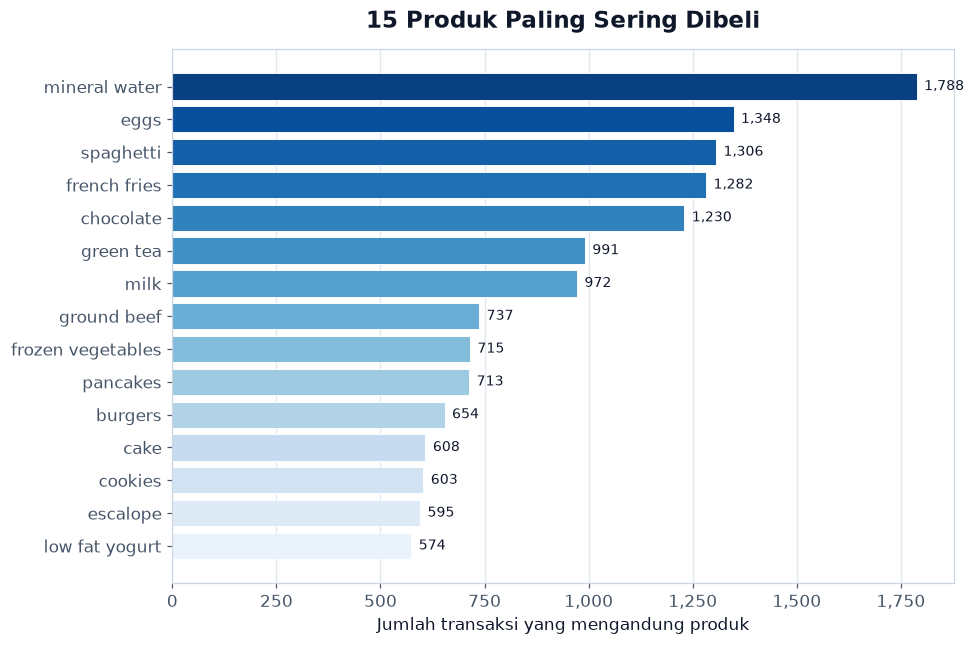

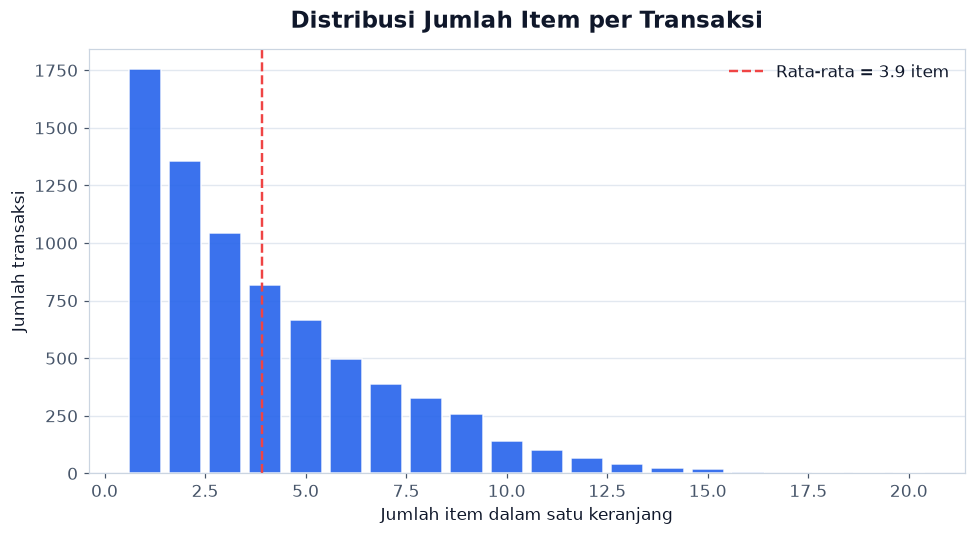

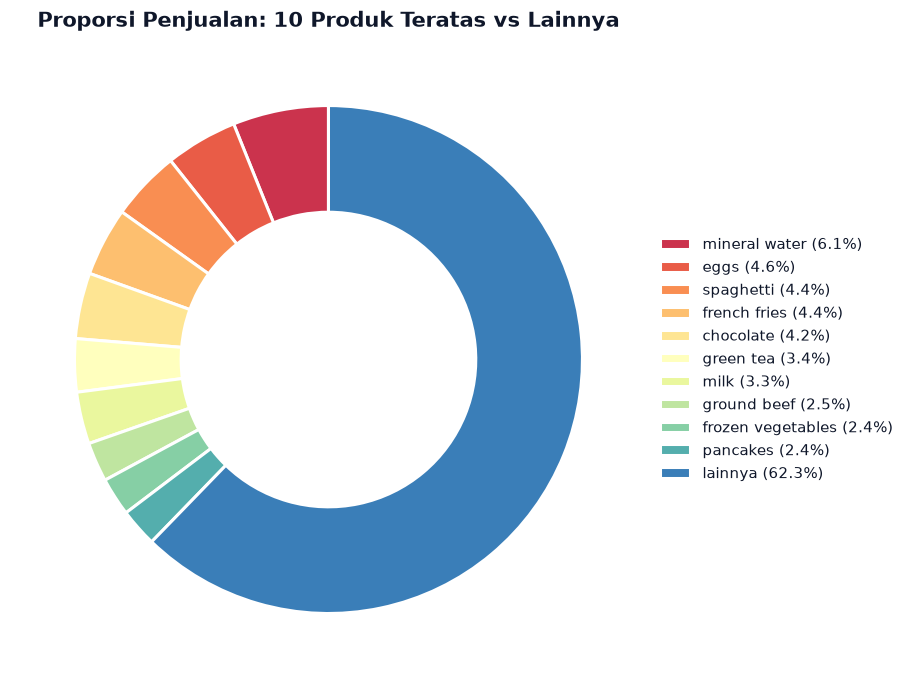

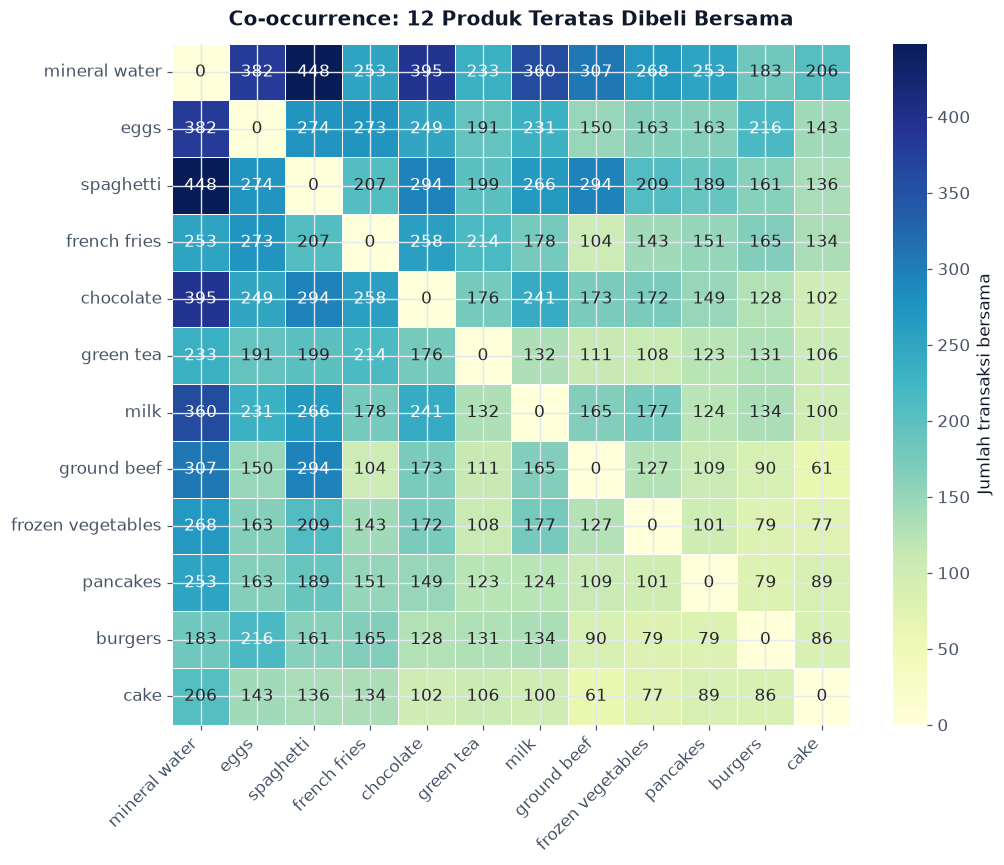


Ukuran matriks one-hot: (7501, 119) -> (transaksi x produk)

Frequent itemsets (min_support=0.005): 725
  panjang 1: 101
  panjang 2: 451
  panjang 3: 173

Total aturan asosiasi (lift >= 1): 1832
Aturan kuat (lift>=1.5, conf>=0.2): 414


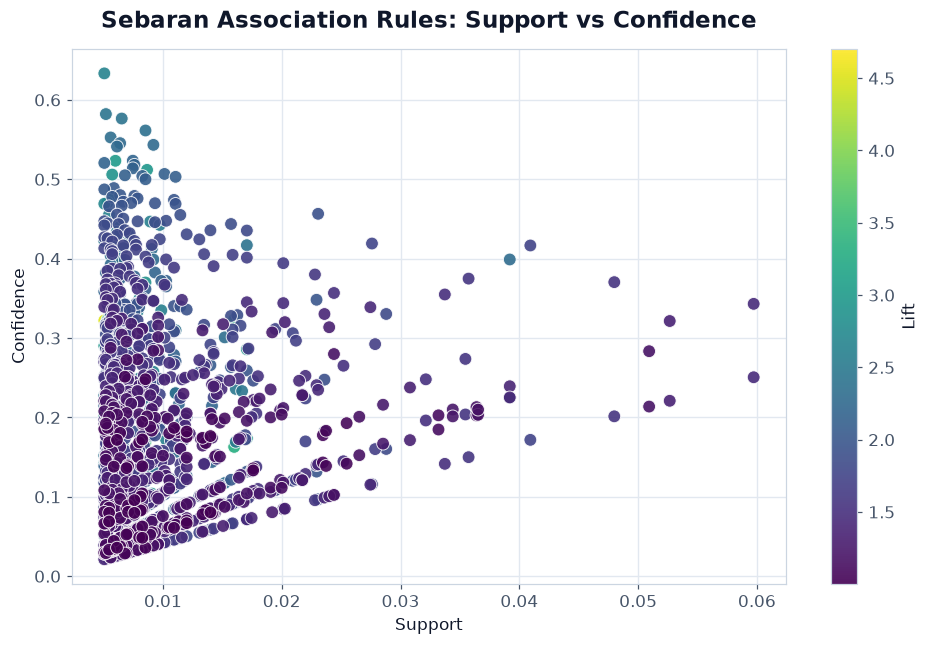

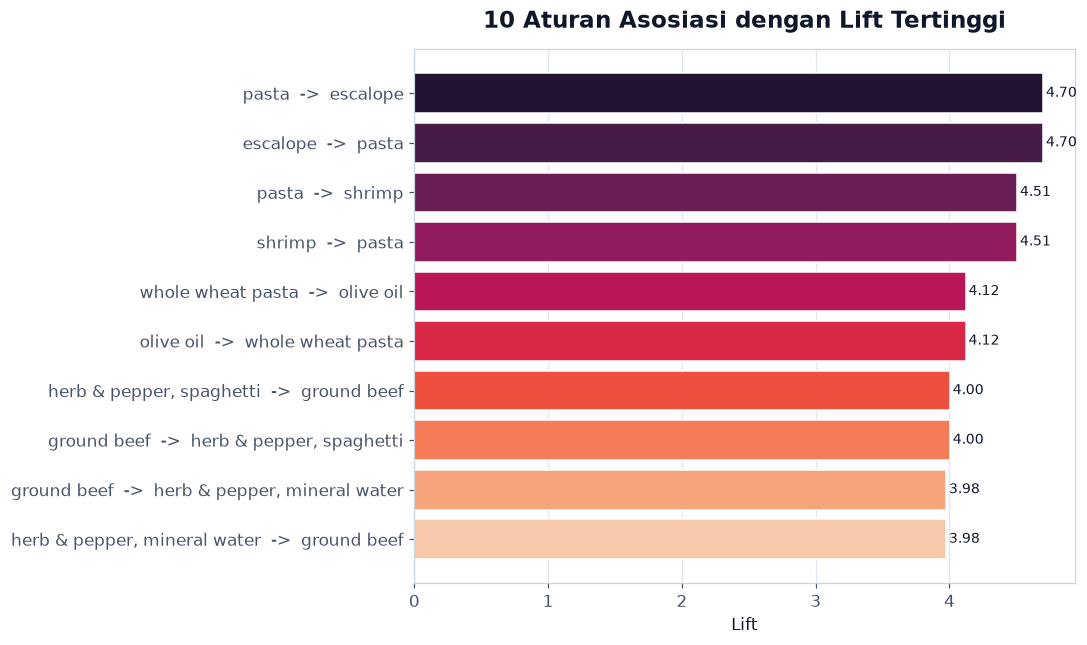

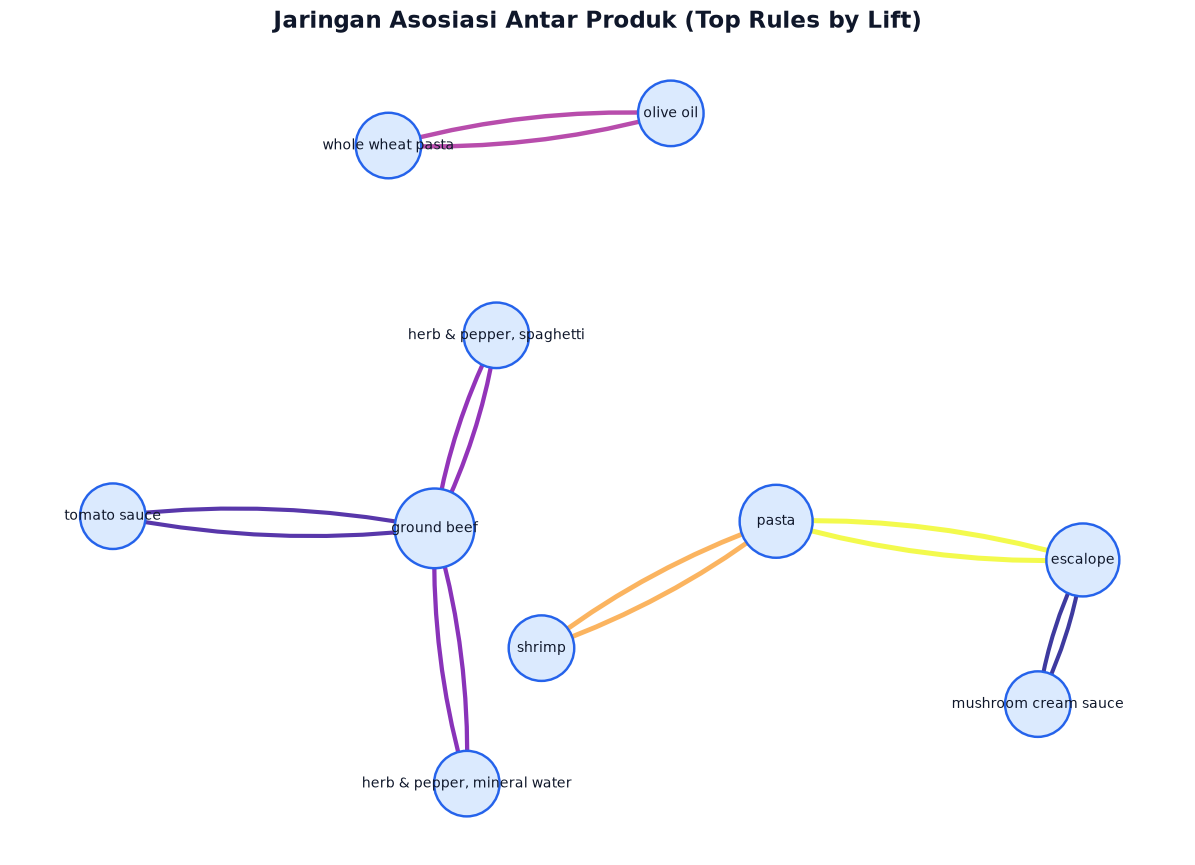


=== 12 ATURAN ASOSIASI TERKUAT (berdasarkan lift) ===
             antecedents_str              consequents_str  support  confidence     lift
                       pasta                     escalope 0.005866    0.372881 4.700812
                    escalope                        pasta 0.005866    0.073950 4.700812
                       pasta                       shrimp 0.005066    0.322034 4.506672
                      shrimp                        pasta 0.005066    0.070896 4.506672
           whole wheat pasta                    olive oil 0.007999    0.271493 4.122410
                   olive oil            whole wheat pasta 0.007999    0.121457 4.122410
    herb & pepper, spaghetti                  ground beef 0.006399    0.393443 4.004360
                 ground beef     herb & pepper, spaghetti 0.006399    0.065129 4.004360
                 ground beef herb & pepper, mineral water 0.006666    0.067843 3.975683
herb & pepper, mineral water                  ground beef 0.00666

In [4]:
import os
import glob
from collections import Counter
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# ---------------------------------------------------------------------
# PENGATURAN FILE (PATH LOKAL)
# ---------------------------------------------------------------------
# Cari otomatis file CSV di folder ini supaya mudah memastikan namanya:
print("File CSV yang ada di folder ini:", glob.glob("*.csv"))

# Nama file dataset. Ganti jika nama di folder Anda sedikit berbeda.
PATH = "Market_Basket_Optimisation.csv"

# Folder untuk menyimpan gambar hasil (otomatis dibuat).
OUTDIR = "hasil_analisis"
os.makedirs(OUTDIR, exist_ok=True)

# Pengaman: beri pesan jelas jika file tidak ditemukan.
if not os.path.exists(PATH):
    raise FileNotFoundError(
        f"File '{PATH}' tidak ditemukan di folder ini.\n"
        f"Pastikan file CSV berada di folder yang sama dengan notebook, "
        f"atau ubah variabel PATH sesuai salah satu nama di daftar di atas."
    )

# ---------------------------------------------------------------------
# STYLING GRAFIK
# ---------------------------------------------------------------------
INK = "#0f172a"
GRID = "#e2e8f0"
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.9,
    "figure.dpi": 110,
})

# =====================================================================
# 1) DATA UNDERSTANDING
# =====================================================================
# Dibaca tanpa header; tiap baris = satu transaksi (panjang bervariasi).
raw = pd.read_csv(PATH, header=None)
print("Bentuk data mentah (baris x kolom maks):", raw.shape)

# Ubah tiap baris menjadi list produk (buang sel kosong / NaN).
transactions = []
for i in range(len(raw)):
    items = [str(x).strip() for x in raw.iloc[i].tolist()
             if pd.notna(x) and str(x).strip() != ""]
    transactions.append(items) 

print(f"Jumlah transaksi: {len(transactions)}")

n_tx = len(transactions)
basket_sizes = [len(t) for t in transactions]
all_items = [item for t in transactions for item in t]
item_counts = Counter(all_items)
unique_items = sorted(item_counts.keys())

print(f"\nJumlah transaksi      : {n_tx}")
print(f"Jumlah produk unik    : {len(unique_items)}")
print(f"Total item terjual    : {len(all_items)}")
print(f"Rata-rata item/keranjang: {np.mean(basket_sizes):.2f} "
      f"(median {int(np.median(basket_sizes))}, "
      f"maks {int(np.max(basket_sizes))}, min {int(np.min(basket_sizes))})")

print("\n10 produk terlaris:")
for name, c in item_counts.most_common(10):
    print(f"  {name:25s} {c:5d}  ({c/n_tx*100:.2f}% transaksi)")

# ----- CHART 1: 15 produk terlaris -----
top15 = item_counts.most_common(15)
names = [t[0] for t in top15][::-1]
vals = [t[1] for t in top15][::-1]
fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette("Blues", len(names))
bars = ax.barh(names, vals, color=colors, edgecolor="white", linewidth=0.6)
ax.set_title("15 Produk Paling Sering Dibeli", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Jumlah transaksi yang mengandung produk")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
for b, v in zip(bars, vals):
    ax.text(v + max(vals)*0.01, b.get_y()+b.get_height()/2, f"{v:,}",
            va="center", fontsize=9, color=INK)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/01_top_items.png", bbox_inches="tight", facecolor="white")
plt.show()

# ----- CHART 2: distribusi ukuran keranjang -----
fig, ax = plt.subplots(figsize=(9, 5))
size_counts = Counter(basket_sizes)
xs = sorted(size_counts.keys())
ys = [size_counts[x] for x in xs]
ax.bar(xs, ys, color="#2563eb", edgecolor="white", alpha=0.9)
ax.set_title("Distribusi Jumlah Item per Transaksi", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Jumlah item dalam satu keranjang")
ax.set_ylabel("Jumlah transaksi")
ax.axvline(np.mean(basket_sizes), color="#ef4444", linestyle="--", linewidth=1.6,
           label=f"Rata-rata = {np.mean(basket_sizes):.1f} item")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/02_basket_size.png", bbox_inches="tight", facecolor="white")
plt.show()

# ----- CHART 3: proporsi 10 produk teratas (donut) -----
top10 = item_counts.most_common(10)
labels = [t[0] for t in top10]
sizes = [t[1] for t in top10]
labels.append("lainnya")
sizes.append(len(all_items) - sum(sizes))
fig, ax = plt.subplots(figsize=(8, 7))
wedge_colors = sns.color_palette("Spectral", len(labels))
wedges, _ = ax.pie(sizes, colors=wedge_colors, startangle=90,
                   wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2))
ax.legend(wedges, [f"{l} ({s/len(all_items)*100:.1f}%)" for l, s in zip(labels, sizes)],
          loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=10)
ax.set_title("Proporsi Penjualan: 10 Produk Teratas vs Lainnya",
             fontsize=14, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/03_share_donut.png", bbox_inches="tight", facecolor="white")
plt.show()

# ----- CHART 7: heatmap co-occurrence 12 produk teratas -----
top_items_names = [t[0] for t in item_counts.most_common(12)]
idx = {name: i for i, name in enumerate(top_items_names)}
mat = np.zeros((12, 12))
for t in transactions:
    present = [it for it in set(t) if it in idx]
    for a, b in combinations(present, 2):
        mat[idx[a]][idx[b]] += 1
        mat[idx[b]][idx[a]] += 1
co = pd.DataFrame(mat, index=top_items_names, columns=top_items_names).astype(int)
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(co, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5,
            linecolor="white", cbar_kws={"label": "Jumlah transaksi bersama"}, ax=ax)
ax.set_title("Co-occurrence: 12 Produk Teratas Dibeli Bersama",
             fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/07_cooccurrence.png", bbox_inches="tight", facecolor="white")
plt.show()

# =====================================================================
# 2) DATA PREPARATION - one-hot encoding
# =====================================================================
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_oh = pd.DataFrame(te_ary, columns=te.columns_)
print("\nUkuran matriks one-hot:", df_oh.shape, "-> (transaksi x produk)")

# =====================================================================
# 3) MODELLING - Apriori + Association Rules
# =====================================================================
MIN_SUPPORT = 0.005   # 0.5% -> muncul di ~38 transaksi atau lebih
freq_itemsets = apriori(df_oh, min_support=MIN_SUPPORT, use_colnames=True)
freq_itemsets["length"] = freq_itemsets["itemsets"].apply(len)
freq_itemsets = freq_itemsets.sort_values("support", ascending=False)
print(f"\nFrequent itemsets (min_support={MIN_SUPPORT}): {len(freq_itemsets)}")
print(f"  panjang 1: {(freq_itemsets.length==1).sum()}")
print(f"  panjang 2: {(freq_itemsets.length==2).sum()}")
print(f"  panjang 3: {(freq_itemsets.length==3).sum()}")

rules = association_rules(freq_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)
print(f"\nTotal aturan asosiasi (lift >= 1): {len(rules)}")

def fs(s):
    return ", ".join(sorted(list(s)))

rules["antecedents_str"] = rules["antecedents"].apply(fs)
rules["consequents_str"] = rules["consequents"].apply(fs)

strong = rules[(rules["lift"] >= 1.5) & (rules["confidence"] >= 0.2)]
print(f"Aturan kuat (lift>=1.5, conf>=0.2): {len(strong)}")

# =====================================================================
# 4) EVALUATION - visualisasi metrik
# =====================================================================
# ----- CHART 4: scatter support vs confidence (warna = lift) -----
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(rules["support"], rules["confidence"], c=rules["lift"],
                cmap="viridis", s=70, edgecolor="white", linewidth=0.6, alpha=0.9)
plt.colorbar(sc).set_label("Lift", fontsize=11)
ax.set_title("Sebaran Association Rules: Support vs Confidence",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Support"); ax.set_ylabel("Confidence")
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/04_scatter_rules.png", bbox_inches="tight", facecolor="white")
plt.show()

# ----- CHART 5: 10 aturan dengan lift tertinggi -----
tr = rules.sort_values("lift", ascending=False).head(10).copy()
tr["label"] = tr["antecedents_str"] + "  ->  " + tr["consequents_str"]
tr = tr[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("rocket_r", len(tr))
bars = ax.barh(tr["label"], tr["lift"], color=colors, edgecolor="white")
ax.set_title("10 Aturan Asosiasi dengan Lift Tertinggi",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Lift")
for b, v in zip(bars, tr["lift"]):
    ax.text(v+0.02, b.get_y()+b.get_height()/2, f"{v:.2f}", va="center", fontsize=9)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/05_top_rules.png", bbox_inches="tight", facecolor="white")
plt.show()

# ----- CHART 6: jaringan asosiasi -----
G = nx.DiGraph()
for _, r in rules.sort_values("lift", ascending=False).head(14).iterrows():
    G.add_edge(r["antecedents_str"], r["consequents_str"], weight=r["lift"])
fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G, k=1.4, seed=42)
weights = [G[u][v]["weight"] for u, v in G.edges()]
node_sizes = [1400 + 220*G.degree(n) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#dbeafe",
                       edgecolors="#2563eb", linewidths=1.6, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w*0.7 for w in weights], edge_color=weights,
                       edge_cmap=plt.cm.plasma, arrowsize=18, arrowstyle="-|>",
                       alpha=0.8, connectionstyle="arc3,rad=0.08", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color=INK, ax=ax)
ax.set_title("Jaringan Asosiasi Antar Produk (Top Rules by Lift)",
             fontsize=15, fontweight="bold", pad=10)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/06_network.png", bbox_inches="tight", facecolor="white")
plt.show()

# =====================================================================
# TABEL ATURAN UNGGULAN + SIMPAN HASIL
# =====================================================================
top_rules = rules.sort_values("lift", ascending=False).head(12)
print("\n=== 12 ATURAN ASOSIASI TERKUAT (berdasarkan lift) ===")
print(top_rules[["antecedents_str", "consequents_str",
                 "support", "confidence", "lift"]].to_string(index=False))

# Simpan tabel aturan ke CSV (opsional, untuk lampiran portofolio)
top_rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]] \
    .to_csv(f"{OUTDIR}/aturan_asosiasi_teratas.csv", index=False)

print(f"\nSelesai. Semua gambar & tabel tersimpan di folder: '{OUTDIR}'")